# AUC Analysis for Future and Past Predictions

This notebook calculates Area Under Curve (AUC) for future and past predictions across different time window definitions.

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import argparse
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import integrate
import tfsplt_future_past_utils as pu

In [25]:
# Define parameters
class Args(argparse.Namespace):
    rois = ["IFG","MTG", "STG","preCG","postCG", "rostralmiddlefrontal",
        "superiorfrontal", "supramarginal", "ITG", "TP", "fusiform", "All"]
    
    lines = ["joint", "word", "sentence", "sentence2"]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    legends = ["joint", "word", "future", "past"]

    lags = {
        "lags_all": np.arange(-60000, 60001, 50),
        "lags_plt": np.arange(-60000, 60001, 50),
        "lag_ticks": np.arange(-60000, 60001, 10000),
        "lag_tick_labels": np.arange(-60, 60.001, 10),
    }
    
args = Args()

In [85]:
# Load data
res_d = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs"
thresh_single = 0.1

# Load comprehension and production data
df_comp = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_comp.csv", 
    thresh_single
)

df_prod = pu.load_res_add_roi_threshold(
    f"{res_d}/ij-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph-translate-control_pca300_drop-short_mistral_prod.csv", 
    thresh_single
)

# Rename lag columns to numeric values
lag_cols = np.arange(-60000, 60001, 50)
for df in [df_comp, df_prod]:
    # Rename first 2401 columns (0 to 2400) to lag values
    n_lag_cols = len(lag_cols)
    new_columns = list(lag_cols) + list(df.columns[n_lag_cols:])
    df.columns = new_columns

print(f"Comprehension data shape: {df_comp.shape}")
print(f"Production data shape: {df_prod.shape}")
print(f"\nLabel3 values in comp: {df_comp['label3'].value_counts().to_dict()}")
print(f"Label3 values in prod: {df_prod['label3'].value_counts().to_dict()}")

Comprehension data shape: (1168, 2406)
Production data shape: (1064, 2406)

Label3 values in comp: {'joint': 292, 'word': 292, 'sentence': 292, 'sentence2': 292}
Label3 values in prod: {'joint': 266, 'word': 266, 'sentence': 266, 'sentence2': 266}


In [86]:
def calculate_auc(df, label3_val, lag_start, lag_end):
    """
    Calculate AUC for electrodes with a specific label3 value within a lag window.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with lag columns and label3
    label3_val : str
        'sentence' or 'sentence2'
    lag_start : int
        Start of lag window (ms)
    lag_end : int
        End of lag window (ms)
    
    Returns:
    --------
    pd.DataFrame with electrode, subject, roi, auc columns
    """
    # Filter by label3
    df_filt = df[df['label3'] == label3_val].copy()
    
    # Get lag columns within window (columns can be strings, integers, or floats)
    lag_cols = []
    lag_vals = []
    for col in df_filt.columns:
        # Check if column is numeric (int, float, or numpy numeric types)
        # numpy types need special handling - convert to python types for comparison
        if isinstance(col, (np.integer, np.floating)):
            col_val = float(col)
            if lag_start <= col_val <= lag_end:
                lag_cols.append(col)
                lag_vals.append(col_val)
        elif isinstance(col, (int, float)):
            col_val = float(col)
            if lag_start <= col_val <= lag_end:
                lag_cols.append(col)
                lag_vals.append(col_val)
        elif isinstance(col, str):
            # Try to convert string to numeric
            try:
                col_val = float(col)
                if lag_start <= col_val <= lag_end:
                    lag_cols.append(col)
                    lag_vals.append(col_val)
            except (ValueError, TypeError):
                continue
    
    if len(lag_cols) == 0:
        print(f"Warning: No lag columns found in window [{lag_start}, {lag_end}]")
        return pd.DataFrame(columns=['subject', 'electrode', 'roi', 'label3', 'lag_start', 'lag_end', 'auc', 'n_lags'])
    
    # Sort by numeric values
    sorted_indices = np.argsort(lag_vals)
    lag_cols_sorted = [lag_cols[i] for i in sorted_indices]
    lag_vals_sorted = [lag_vals[i] for i in sorted_indices]
    
    results = []
    
    for idx, row in df_filt.iterrows():
        # Get values in time window
        vals = row[lag_cols_sorted].values
        
        # Calculate AUC using trapezoidal rule
        # x values are the numeric lag values, y values are the correlations
        auc = integrate.trapezoid(vals, x=lag_vals_sorted)
        
        results.append({
            'subject': row['subject'],
            'electrode': row['electrode'],
            'roi': row.get('roi', 'unknown'),
            'label3': label3_val,
            'lag_start': lag_start,
            'lag_end': lag_end,
            'auc': auc,
            'n_lags': len(lag_cols_sorted)
        })
    
    return pd.DataFrame(results)

In [64]:
# Define time windows
# Both future and past use the same threshold values
# Future: cumulative AUC from -60000 to threshold
# Past: cumulative AUC from threshold to 60000
thresholds = [-500, -300, 0, 300, 500]

print(f"Thresholds: {thresholds}")
print("\nWindow definitions:")
print("  Future (sentence): cumulative AUC from -60000ms to threshold")
print("  Past (sentence2): cumulative AUC from threshold to 60000ms")

Thresholds: [-500, -300, 0, 300, 500]

Window definitions:
  Future (sentence): cumulative AUC from -60000ms to threshold
  Past (sentence2): cumulative AUC from threshold to 60000ms


In [87]:
# Calculate AUC for all conditions
all_results = []

# Comprehension - Future (sentence)
# Window: cumulative from -60000 to threshold
print("\nCalculating AUC for Comprehension Future...")
for threshold in thresholds:
    auc_df = calculate_auc(df_comp, 'sentence', lag_start=-5000, lag_end=threshold)
    auc_df['mode'] = 'comp'
    auc_df['direction'] = 'future'
    auc_df['window_def'] = f'-60000 to {threshold}'
    auc_df['threshold'] = threshold
    all_results.append(auc_df)
    if len(auc_df) > 0:
        print(f"  -60000 to {threshold}: n={len(auc_df)}, mean AUC={auc_df['auc'].mean():.2f}")

# Comprehension - Past (sentence2)
# Window: cumulative from threshold to 60000
print("\nCalculating AUC for Comprehension Past...")
for threshold in thresholds:
    auc_df = calculate_auc(df_comp, 'sentence2', lag_start=threshold, lag_end=5000)
    auc_df['mode'] = 'comp'
    auc_df['direction'] = 'past'
    auc_df['window_def'] = f'{threshold} to 60000'
    auc_df['threshold'] = threshold
    all_results.append(auc_df)
    if len(auc_df) > 0:
        print(f"  {threshold} to 60000: n={len(auc_df)}, mean AUC={auc_df['auc'].mean():.2f}")

# Production - Future (sentence)
# Window: cumulative from -60000 to threshold
print("\nCalculating AUC for Production Future...")
for threshold in thresholds:
    auc_df = calculate_auc(df_prod, 'sentence', lag_start=-5000, lag_end=threshold)
    auc_df['mode'] = 'prod'
    auc_df['direction'] = 'future'
    auc_df['window_def'] = f'-60000 to {threshold}'
    auc_df['threshold'] = threshold
    all_results.append(auc_df)
    if len(auc_df) > 0:
        print(f"  -60000 to {threshold}: n={len(auc_df)}, mean AUC={auc_df['auc'].mean():.2f}")

# Production - Past (sentence2)
# Window: cumulative from threshold to 60000
print("\nCalculating AUC for Production Past...")
for threshold in thresholds:
    auc_df = calculate_auc(df_prod, 'sentence2', lag_start=threshold, lag_end=5000)
    auc_df['mode'] = 'prod'
    auc_df['direction'] = 'past'
    auc_df['window_def'] = f'{threshold} to 60000'
    auc_df['threshold'] = threshold
    all_results.append(auc_df)
    if len(auc_df) > 0:
        print(f"  {threshold} to 60000: n={len(auc_df)}, mean AUC={auc_df['auc'].mean():.2f}")

# Combine all results
auc_results = pd.concat(all_results, ignore_index=True)
print(f"\nTotal AUC calculations: {len(auc_results)}")


Calculating AUC for Comprehension Future...
  -60000 to -500: n=292, mean AUC=52.25
  -60000 to -300: n=292, mean AUC=56.34
  -60000 to 0: n=292, mean AUC=63.19
  -60000 to -300: n=292, mean AUC=56.34
  -60000 to 0: n=292, mean AUC=63.19
  -60000 to 300: n=292, mean AUC=72.27
  -60000 to 500: n=292, mean AUC=80.08

Calculating AUC for Comprehension Past...
  -60000 to 300: n=292, mean AUC=72.27
  -60000 to 500: n=292, mean AUC=80.08

Calculating AUC for Comprehension Past...
  -500 to 60000: n=292, mean AUC=113.09
  -300 to 60000: n=292, mean AUC=102.48
  -500 to 60000: n=292, mean AUC=113.09
  -300 to 60000: n=292, mean AUC=102.48
  0 to 60000: n=292, mean AUC=87.43
  300 to 60000: n=292, mean AUC=74.38
  0 to 60000: n=292, mean AUC=87.43
  300 to 60000: n=292, mean AUC=74.38
  500 to 60000: n=292, mean AUC=67.04

Calculating AUC for Production Future...
  -60000 to -500: n=266, mean AUC=49.77
  500 to 60000: n=292, mean AUC=67.04

Calculating AUC for Production Future...
  -60000 to

In [68]:
# Display summary statistics
print("\n" + "="*80)
print("AUC SUMMARY BY CONDITION")
print("="*80)

summary = auc_results.groupby(['mode', 'direction', 'lag_start', 'lag_end'])['auc'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print(summary)


AUC SUMMARY BY CONDITION
                                  count    mean    std     min     max
mode direction lag_start lag_end                                      
comp future    -5000     -500       292   52.25  48.31  -38.01  396.56
                         -300       292   56.34  50.78  -38.15  414.19
                          0         292   63.19  54.51  -38.36  440.63
                          300       292   72.27  58.51  -37.83  467.08
                          500       292   80.08  61.07  -37.31  484.71
     past      -500       5000      292  113.09  76.86 -500.78  521.95
               -300       5000      292  102.48  73.13 -480.55  502.97
                0         5000      292   87.43  67.49 -449.05  474.51
                300       5000      292   74.38  62.19 -414.56  446.05
                500       5000      292   67.04  58.80 -393.25  427.07
prod future    -5000     -500       266   49.77  50.85  -49.42  311.02
                         -300       266   56.45  55

In [69]:
# auc_results.head(1000)



In [70]:
# Filter electrodes based on joint condition threshold
# Keep only electrodes that have max correlation > threshold in at least one df's label3=='joint' rows

thresh_joint = 0.1

# Get electrodes that pass threshold in label3=='joint' from either comp or prod
joint_comp = df_comp[df_comp['label3'] == 'joint'].copy()
joint_prod = df_prod[df_prod['label3'] == 'joint'].copy()

# Get max correlation values across all lag columns for each electrode
lag_cols_numeric = [col for col in joint_comp.columns if isinstance(col, (np.integer, np.floating))]

# Find electrodes with max > threshold
comp_max = joint_comp[lag_cols_numeric].max(axis=1)
prod_max = joint_prod[lag_cols_numeric].max(axis=1)

# Get electrodes that pass threshold in at least one condition
comp_pass = joint_comp[comp_max > thresh_joint][['subject', 'electrode']].copy()
prod_pass = joint_prod[prod_max > thresh_joint][['subject', 'electrode']].copy()

# Combine and get unique electrodes
all_pass = pd.concat([comp_pass, prod_pass]).drop_duplicates()

print(f"Electrodes passing threshold {thresh_joint} in joint condition:")
print(f"  Comprehension: {len(comp_pass)}")
print(f"  Production: {len(prod_pass)}")
print(f"  Total unique: {len(all_pass)}")

# Filter auc_results to only include these electrodes
auc_results_filtered = auc_results.merge(
    all_pass,
    on=['subject', 'electrode'],
    how='inner'
)

print(f"\nAUC results before filtering: {len(auc_results)}")
print(f"AUC results after filtering: {len(auc_results_filtered)}")

Electrodes passing threshold 0.1 in joint condition:
  Comprehension: 292
  Production: 266
  Total unique: 351

AUC results before filtering: 5580
AUC results after filtering: 5580


Production Future pivot shape: (249, 8)
Threshold columns: [-500, -300, 0, 300, 500]


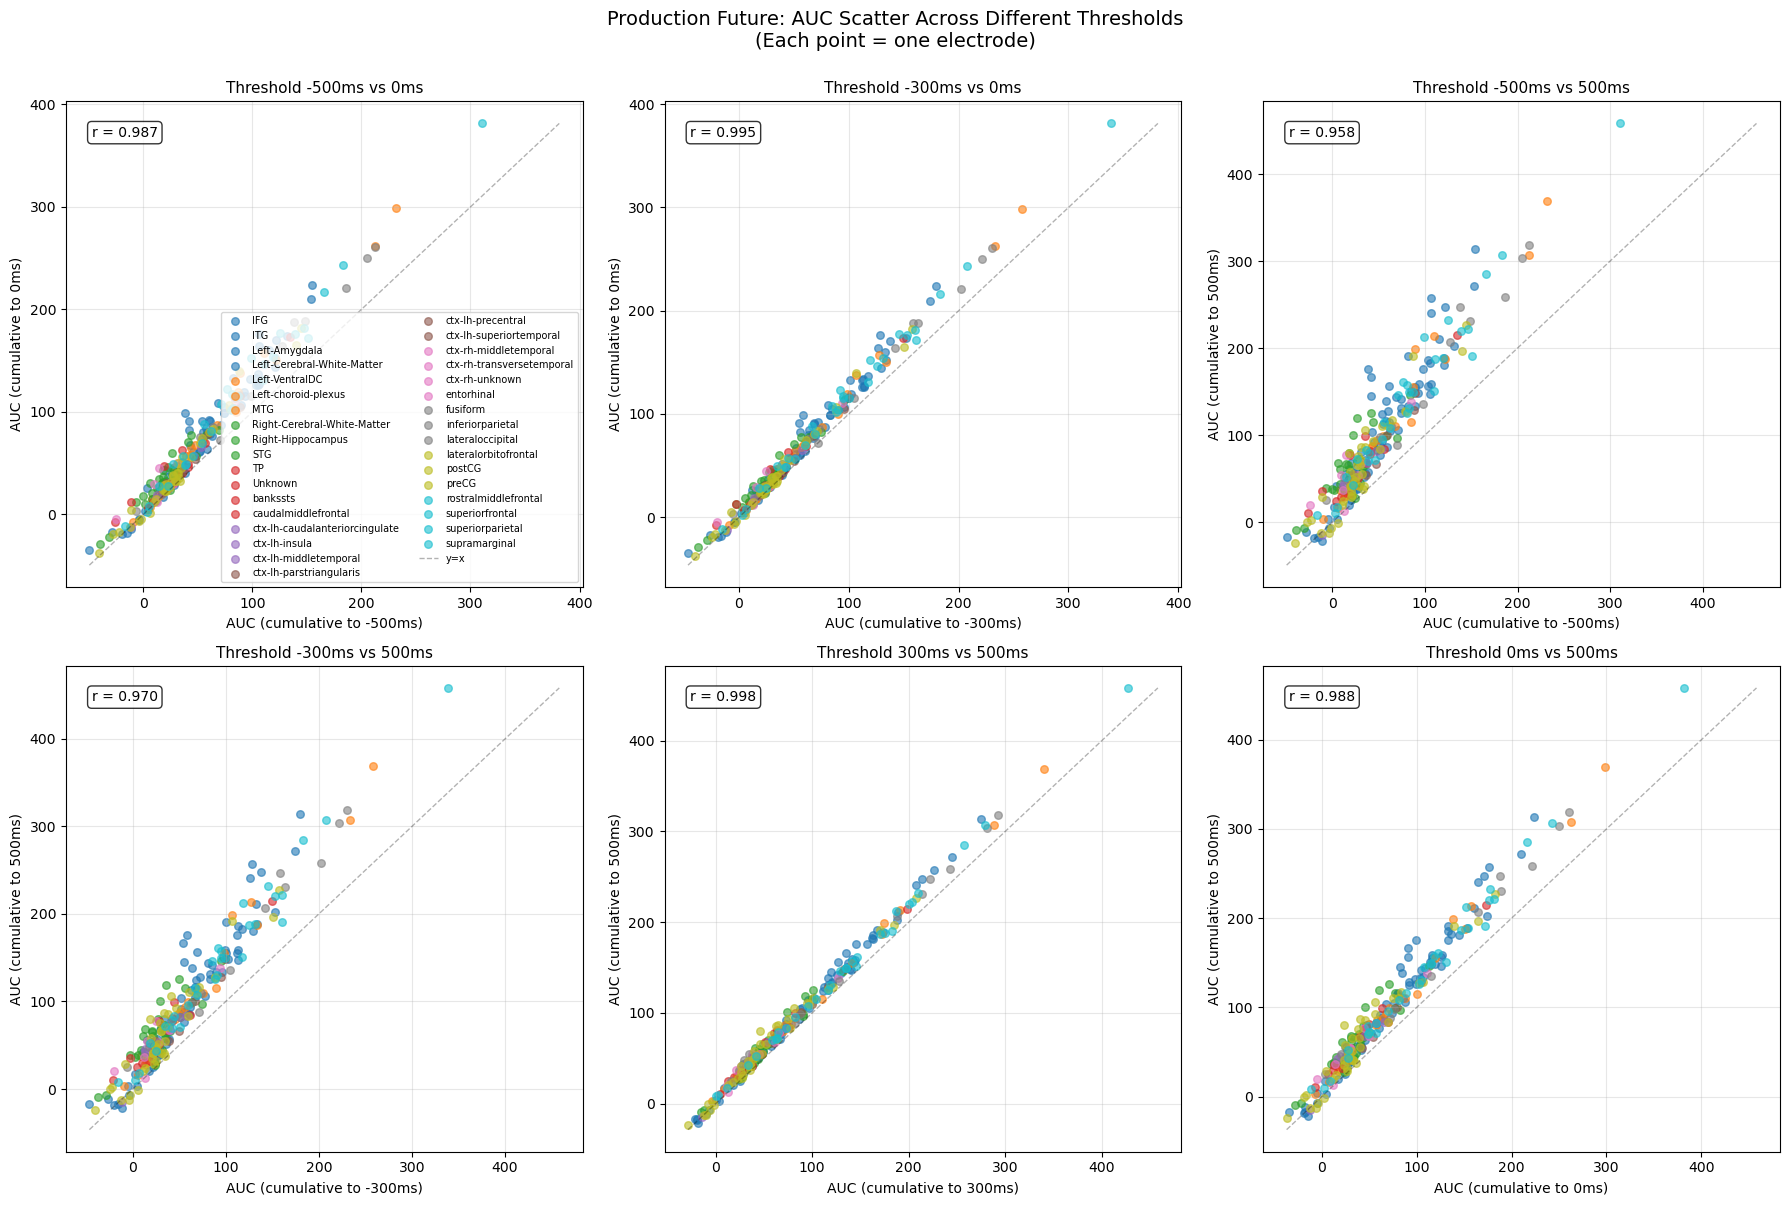

In [71]:
# Scatterplot: Production Future AUC across different lags (thresholds)
# Each point is an electrode, comparing AUC values at different threshold pairs

prod_future = auc_results_filtered[(auc_results_filtered['mode'] == 'prod') & 
                                    (auc_results_filtered['direction'] == 'future')].copy()

# Create pivot table: electrodes × thresholds
pivot_prod_future = prod_future.pivot_table(
    index=['subject', 'electrode', 'roi'],
    columns='threshold',
    values='auc'
).reset_index()

print(f"Production Future pivot shape: {pivot_prod_future.shape}")
print(f"Threshold columns: {[col for col in pivot_prod_future.columns if isinstance(col, (int, float, np.number))]}")

# Create scatter plots comparing different threshold pairs
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

threshold_pairs = [
    (-500, 0),
    (-300, 0),
    (-500, 500),
    (-300, 500),
    (300, 500),
    (0, 500)
]

for idx, (t1, t2) in enumerate(threshold_pairs):
    ax = axes[idx]
    
    # Get data for this pair
    x_data = pivot_prod_future[t1]
    y_data = pivot_prod_future[t2]
    
    # Color by ROI if available
    if 'roi' in pivot_prod_future.columns:
        rois = pivot_prod_future['roi']
        unique_rois = sorted(rois.unique())
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_rois)))
        roi_color_map = dict(zip(unique_rois, colors))
        
        for roi in unique_rois:
            mask = rois == roi
            ax.scatter(x_data[mask], y_data[mask], 
                      alpha=0.6, s=30, label=roi,
                      color=roi_color_map[roi])
    else:
        ax.scatter(x_data, y_data, alpha=0.6, s=30)
    
    # Add diagonal line
    all_vals = np.concatenate([x_data.dropna(), y_data.dropna()])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax.plot([min_val, max_val], [min_val, max_val], 
           'k--', alpha=0.3, linewidth=1, label='y=x')
    
    # Calculate correlation
    valid_mask = ~(x_data.isna() | y_data.isna())
    if valid_mask.sum() > 0:
        corr = np.corrcoef(x_data[valid_mask], y_data[valid_mask])[0, 1]
        ax.text(0.05, 0.95, f'r = {corr:.3f}', 
               transform=ax.transAxes, 
               fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel(f'AUC (cumulative to {t1}ms)', fontsize=10)
    ax.set_ylabel(f'AUC (cumulative to {t2}ms)', fontsize=10)
    ax.set_title(f'Threshold {t1}ms vs {t2}ms', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add legend only to first subplot
    if idx == 0 and 'roi' in pivot_prod_future.columns:
        ax.legend(loc='lower right', fontsize=7, ncol=2)

plt.suptitle('Production Future: AUC Scatter Across Different Thresholds\n(Each point = one electrode)', 
            fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Merged data shape: (193, 13)


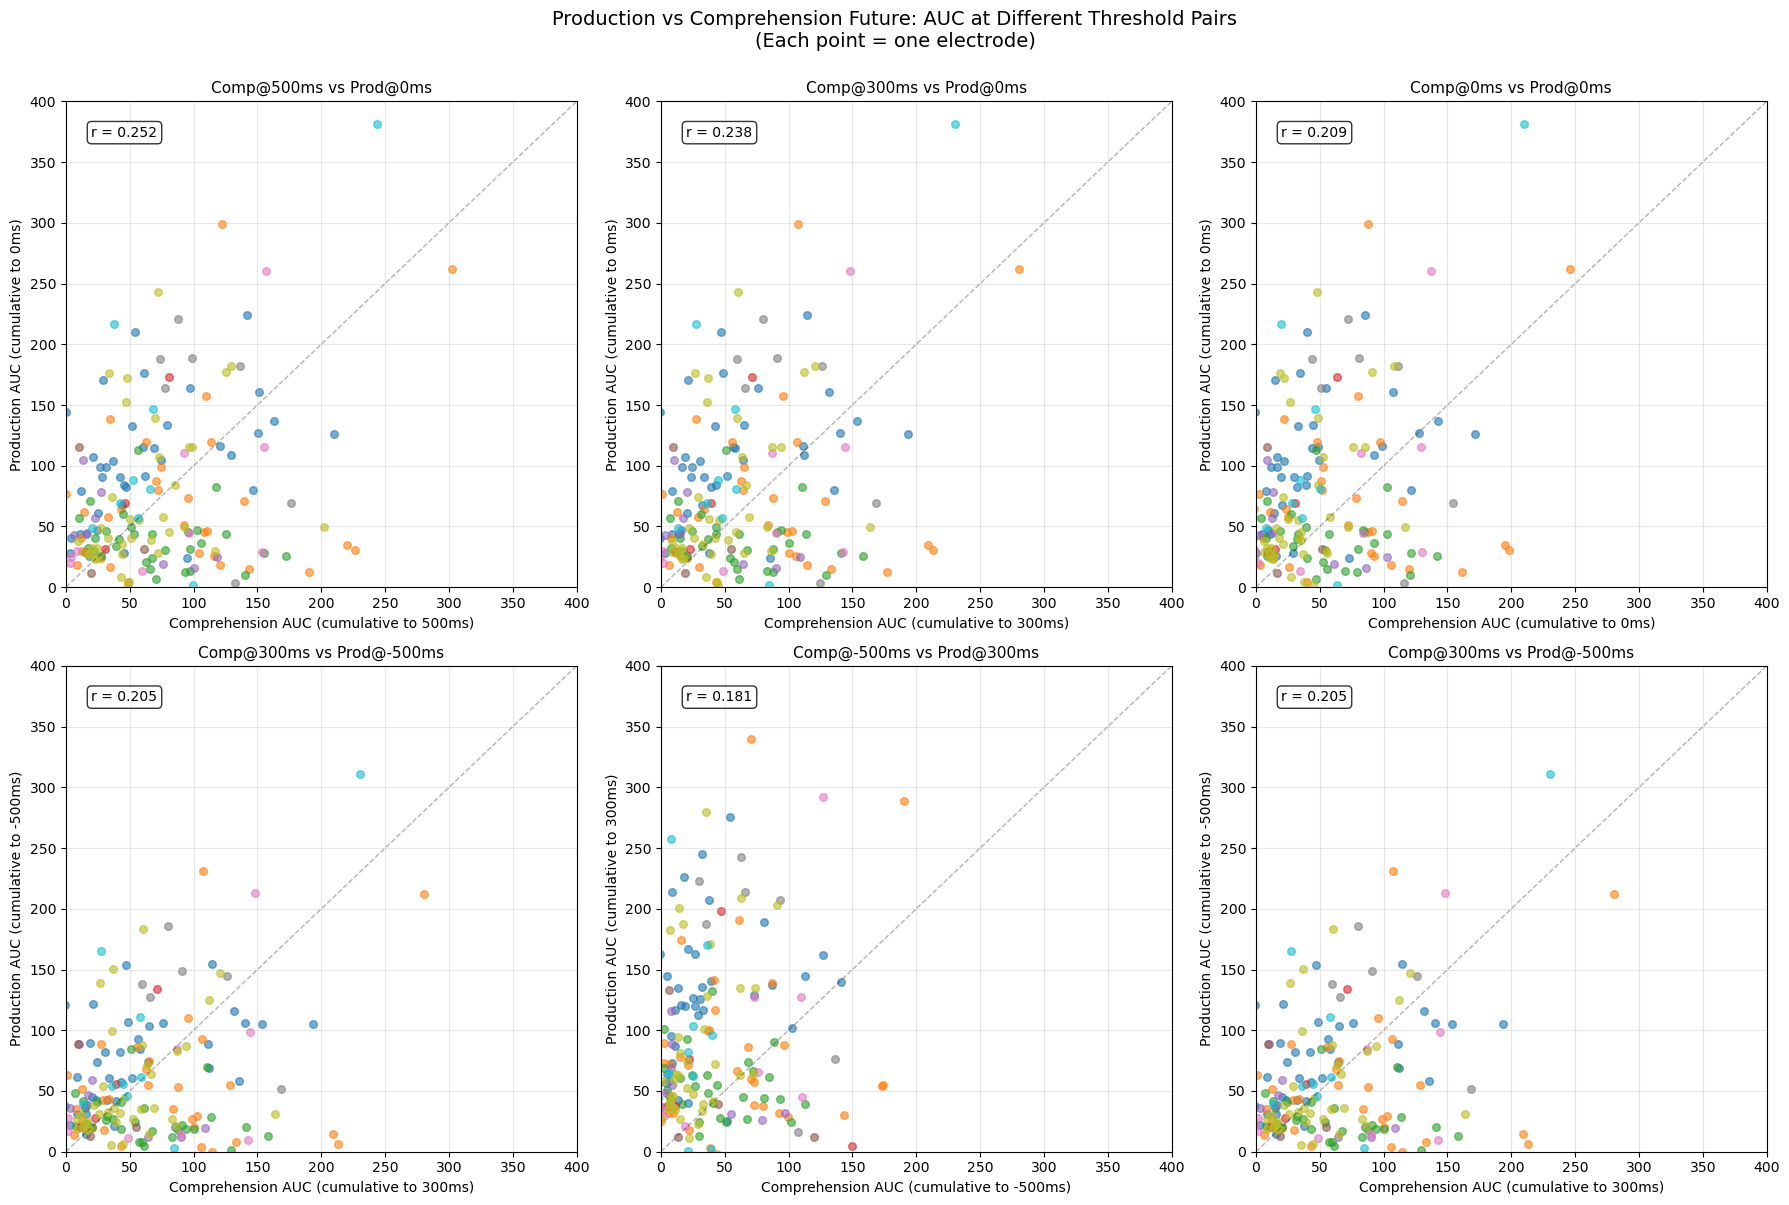

In [73]:
# Scatterplot: Production vs Comprehension Future AUC at different threshold pairs
# Each point is an electrode, comparing prod vs comp at the same lag configuration

# Get future data for both modes
comp_future = auc_results_filtered[(auc_results_filtered['mode'] == 'comp') & 
                                    (auc_results_filtered['direction'] == 'future')].copy()
prod_future = auc_results_filtered[(auc_results_filtered['mode'] == 'prod') & 
                                    (auc_results_filtered['direction'] == 'future')].copy()

# Create pivot tables: electrodes × thresholds
pivot_comp = comp_future.pivot_table(
    index=['subject', 'electrode', 'roi'],
    columns='threshold',
    values='auc'
).reset_index()

pivot_prod = prod_future.pivot_table(
    index=['subject', 'electrode', 'roi'],
    columns='threshold',
    values='auc'
).reset_index()

# Merge on electrode identifiers
merged = pivot_comp.merge(
    pivot_prod,
    on=['subject', 'electrode', 'roi'],
    suffixes=('_comp', '_prod')
)

print(f"Merged data shape: {merged.shape}")

# Create scatter plots comparing prod vs comp at different threshold pairs
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Lag pairs: (comp_threshold, prod_threshold)
threshold_pairs = [
    (500, 0),
    (300, 0),
    (0, 0),
    (300, -500),
    (-500, 300),
    (300, -500)
]

for idx, (t_comp, t_prod) in enumerate(threshold_pairs):
    ax = axes[idx]
    
    # Get data for this pair
    x_col = f'{t_comp}_comp' if f'{t_comp}_comp' in merged.columns else t_comp
    y_col = f'{t_prod}_prod' if f'{t_prod}_prod' in merged.columns else t_prod
    
    # Handle column naming (sometimes without suffix if no conflict)
    try:
        x_data = merged[x_col]
    except KeyError:
        x_data = merged[t_comp]
    
    try:
        y_data = merged[y_col]
    except KeyError:
        y_data = merged[t_prod]
    
    # Color by ROI if available
    if 'roi' in merged.columns:
        rois = merged['roi']
        unique_rois = sorted(rois.unique())
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_rois)))
        roi_color_map = dict(zip(unique_rois, colors))
        
        for roi in unique_rois:
            mask = rois == roi
            ax.scatter(x_data[mask], y_data[mask], 
                      alpha=0.6, s=30,
                      color=roi_color_map[roi])
    else:
        ax.scatter(x_data, y_data, alpha=0.6, s=30)
    
    # Add diagonal line
    ax.plot([0, 400], [0, 400], 
           'k--', alpha=0.3, linewidth=1)
    
    # Calculate correlation
    valid_mask = ~(x_data.isna() | y_data.isna())
    if valid_mask.sum() > 0:
        corr = np.corrcoef(x_data[valid_mask], y_data[valid_mask])[0, 1]
        ax.text(0.05, 0.95, f'r = {corr:.3f}', 
               transform=ax.transAxes, 
               fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel(f'Comprehension AUC (cumulative to {t_comp}ms)', fontsize=10)
    ax.set_ylabel(f'Production AUC (cumulative to {t_prod}ms)', fontsize=10)
    ax.set_title(f'Comp@{t_comp}ms vs Prod@{t_prod}ms', fontsize=11)
    ax.set_xlim(0, 400)
    ax.set_ylim(0, 400)
    ax.grid(True, alpha=0.3)

plt.suptitle('Production vs Comprehension Future: AUC at Different Threshold Pairs\n(Each point = one electrode)', 
            fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Available thresholds: [np.int64(-500), np.int64(-300), np.int64(0), np.int64(300), np.int64(500)]


/tmp/ipykernel_1850395/4049376997.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


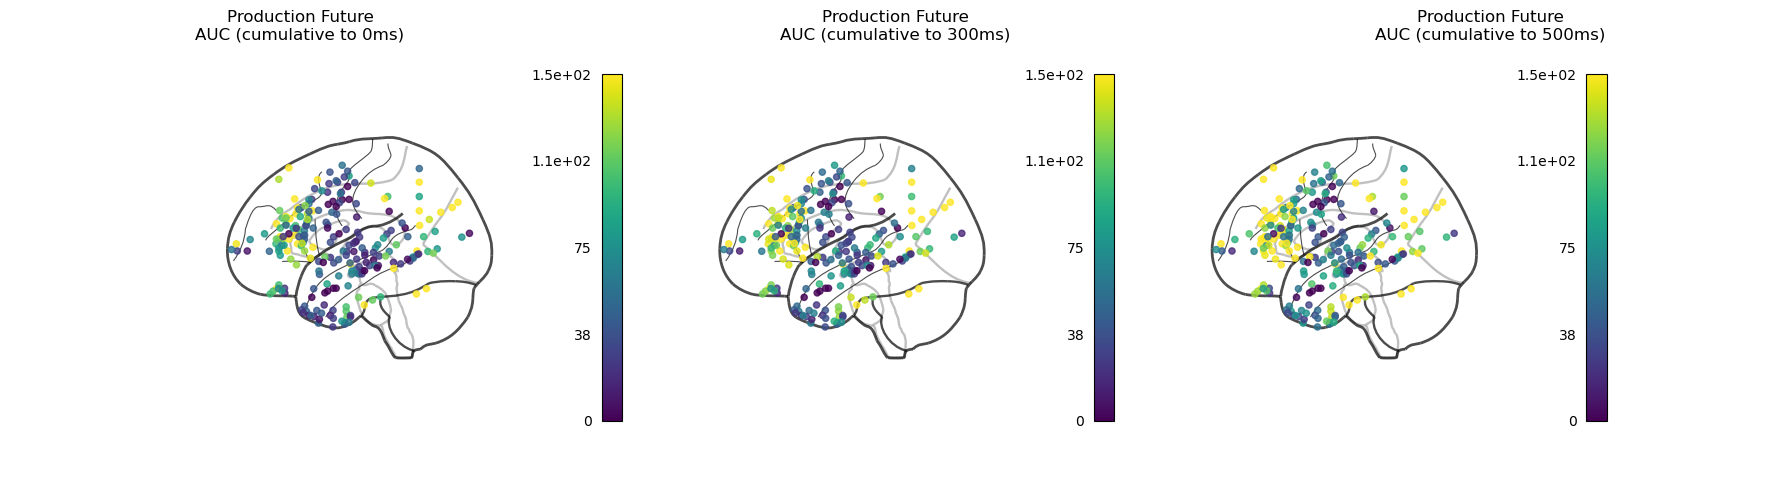

In [88]:
# Brain plots: Production Future at thresholds 0, 300, 500
# Plot AUC values on glassbrain for each threshold

# Note: We need threshold 500, but it's not in our current threshold list
# Let's check what thresholds we have and use the closest available
available_thresholds = sorted(auc_results_filtered['threshold'].unique())
print(f"Available thresholds: {available_thresholds}")

# Use 300 as proxy for 500 if 500 not available
thresholds_to_plot = [0, 300]
if 500 in available_thresholds:
    thresholds_to_plot.append(500)

# Create figure with subplots for production future
fig, axes = plt.subplots(1, len(thresholds_to_plot), figsize=(6*len(thresholds_to_plot), 5))
if len(thresholds_to_plot) == 1:
    axes = [axes]

for idx, threshold in enumerate(thresholds_to_plot):
    # Filter for production future at this threshold
    plot_data = auc_results_filtered[
        (auc_results_filtered['mode'] == 'prod') & 
        (auc_results_filtered['direction'] == 'future') & 
        (auc_results_filtered['threshold'] == threshold)
    ].copy()
    
    if len(plot_data) == 0:
        print(f"Warning: No data for production future at threshold {threshold}")
        continue
    
    # Plot on glassbrain
    pu.plot_effect_glassbrain(
        plot_data,
        effect_col='auc',
        subjects=["625", "676", "717", "798"],
        vmin=0,
        vmax=150,
        ax=axes[idx],
        title=f'Production Future\nAUC (cumulative to {threshold}ms)',
        show=False
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_1850395/1119784015.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


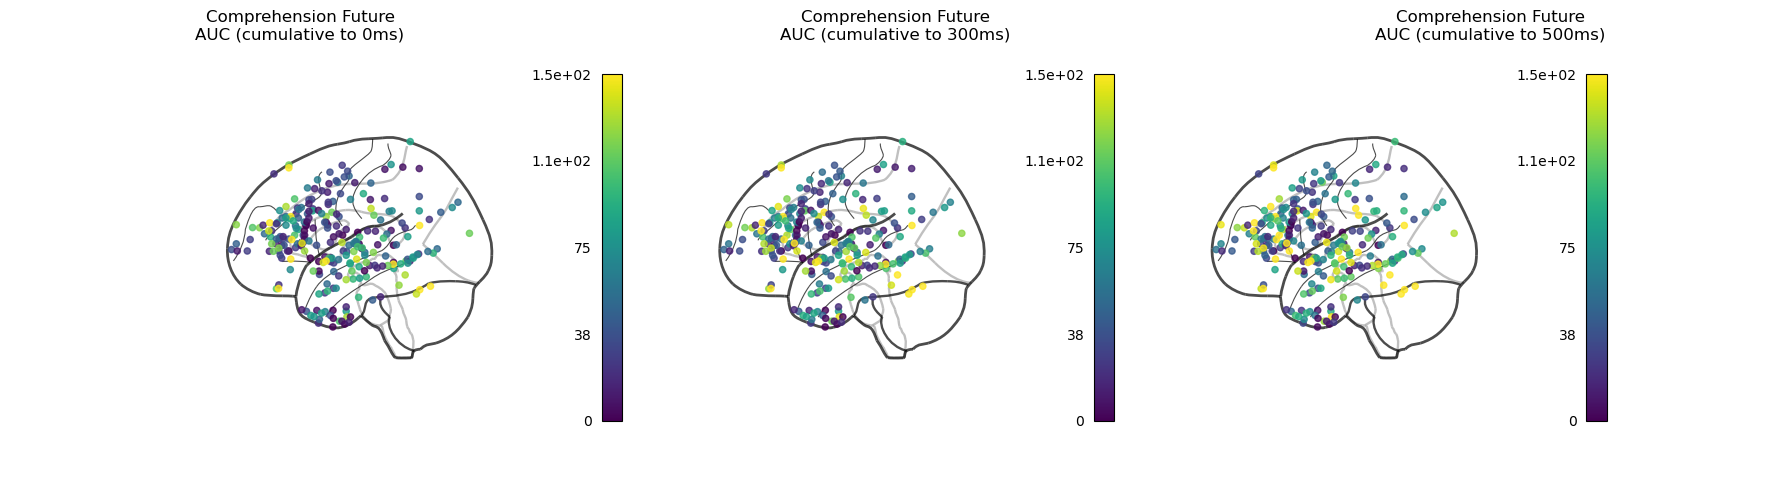

In [89]:
# Brain plots: Comprehension Future at thresholds 0, 300, 500
# Plot AUC values on glassbrain for each threshold

# Use same thresholds as production
thresholds_to_plot = [0, 300]
if 500 in available_thresholds:
    thresholds_to_plot.append(500)

# Create figure with subplots for comprehension future
fig, axes = plt.subplots(1, len(thresholds_to_plot), figsize=(6*len(thresholds_to_plot), 5))
if len(thresholds_to_plot) == 1:
    axes = [axes]

for idx, threshold in enumerate(thresholds_to_plot):
    # Filter for comprehension future at this threshold
    plot_data = auc_results_filtered[
        (auc_results_filtered['mode'] == 'comp') & 
        (auc_results_filtered['direction'] == 'future') & 
        (auc_results_filtered['threshold'] == threshold)
    ].copy()
    
    if len(plot_data) == 0:
        print(f"Warning: No data for comprehension future at threshold {threshold}")
        continue
    
    # Plot on glassbrain
    pu.plot_effect_glassbrain(
        plot_data,
        effect_col='auc',
        subjects=["625", "676", "717", "798"],
        vmin=0,
        vmax=150,
        ax=axes[idx],
        title=f'Comprehension Future\nAUC (cumulative to {threshold}ms)',
        show=False
    )

plt.tight_layout()
plt.show()

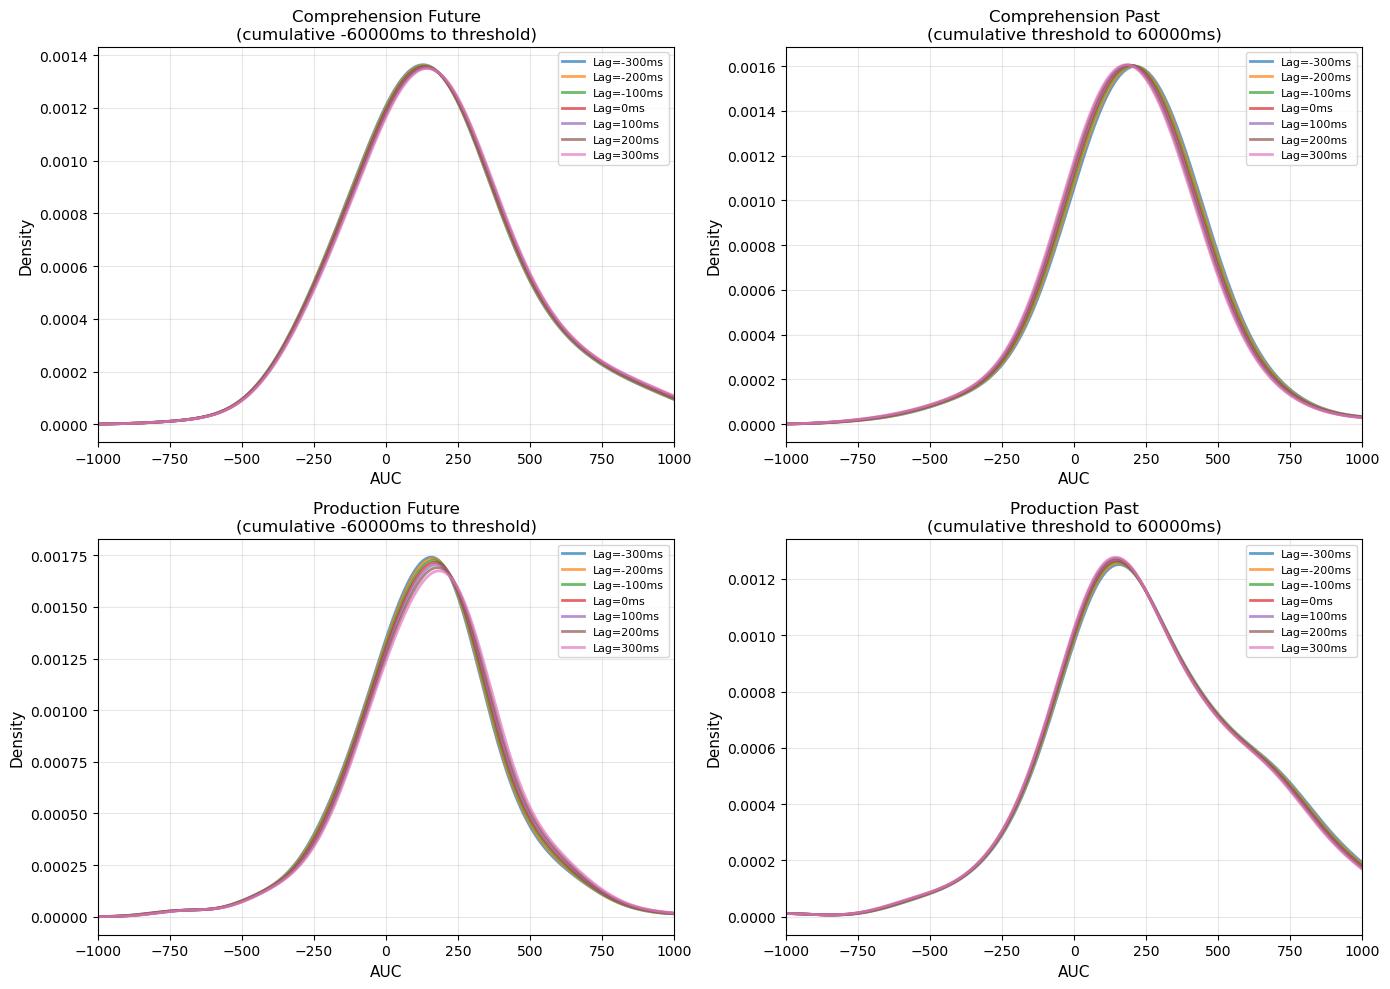


AUC DISTRIBUTION SUMMARY

Comprehension Future:
  Count: 2044
  Mean:  208.9778
  Std:   451.8188
  Min:   -671.2530
  25%:   -1.1913
  50%:   159.1063
  75%:   322.7888
  Max:   5298.9382

Comprehension Past:
  Count: 2044
  Mean:  210.1800
  Std:   416.9958
  Min:   -1405.1309
  25%:   66.5080
  50%:   190.7261
  75%:   332.7709
  Max:   5738.8806

Production Future:
  Count: 1862
  Mean:  169.6374
  Std:   298.7201
  Min:   -755.6160
  25%:   9.0177
  50%:   160.9911
  75%:   290.5418
  Max:   1985.3557

Production Past:
  Count: 1862
  Mean:  286.7910
  Std:   375.5940
  Min:   -1036.1060
  25%:   52.2939
  50%:   219.6877
  75%:   496.9647
  Max:   2295.4185


In [50]:
# Plot KDE distributions for AUC across all thresholds
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Comprehension Future - plot KDE for each threshold
comp_future = auc_results[(auc_results['mode'] == 'comp') & (auc_results['direction'] == 'future')]
for threshold in sorted(comp_future['threshold'].unique()):
    data = comp_future[comp_future['threshold'] == threshold]['auc']
    data.plot(kind='kde', ax=axes[0, 0], linewidth=2, label=f'Lag={threshold}ms', alpha=0.7)
axes[0, 0].set_xlabel('AUC', fontsize=11)
axes[0, 0].set_ylabel('Density', fontsize=11)
axes[0, 0].set_title('Comprehension Future\n(cumulative -60000ms to threshold)', fontsize=12)
axes[0, 0].legend(loc='best', fontsize=8)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(-1000, 1000)

# Comprehension Past - plot KDE for each threshold
comp_past = auc_results[(auc_results['mode'] == 'comp') & (auc_results['direction'] == 'past')]
for threshold in sorted(comp_past['threshold'].unique()):
    data = comp_past[comp_past['threshold'] == threshold]['auc']
    data.plot(kind='kde', ax=axes[0, 1], linewidth=2, label=f'Lag={threshold}ms', alpha=0.7)
axes[0, 1].set_xlabel('AUC', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].set_title('Comprehension Past\n(cumulative threshold to 60000ms)', fontsize=12)
axes[0, 1].legend(loc='best', fontsize=8)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(-1000, 1000)

# Production Future - plot KDE for each threshold
prod_future = auc_results[(auc_results['mode'] == 'prod') & (auc_results['direction'] == 'future')]
for threshold in sorted(prod_future['threshold'].unique()):
    data = prod_future[prod_future['threshold'] == threshold]['auc']
    data.plot(kind='kde', ax=axes[1, 0], linewidth=2, label=f'Lag={threshold}ms', alpha=0.7)
axes[1, 0].set_xlabel('AUC', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].set_title('Production Future\n(cumulative -60000ms to threshold)', fontsize=12)
axes[1, 0].legend(loc='best', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(-1000, 1000)

# Production Past - plot KDE for each threshold
prod_past = auc_results[(auc_results['mode'] == 'prod') & (auc_results['direction'] == 'past')]
for threshold in sorted(prod_past['threshold'].unique()):
    data = prod_past[prod_past['threshold'] == threshold]['auc']
    data.plot(kind='kde', ax=axes[1, 1], linewidth=2, label=f'Lag={threshold}ms', alpha=0.7)
axes[1, 1].set_xlabel('AUC', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].set_title('Production Past\n(cumulative threshold to 60000ms)', fontsize=12)
axes[1, 1].legend(loc='best', fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(-1000, 1000)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("AUC DISTRIBUTION SUMMARY")
print("="*80)
for (mode, direction), data in auc_results.groupby(['mode', 'direction']):
    mode_name = "Comprehension" if mode == "comp" else "Production"
    print(f"\n{mode_name} {direction.capitalize()}:")
    print(f"  Count: {len(data)}")
    print(f"  Mean:  {data['auc'].mean():.4f}")
    print(f"  Std:   {data['auc'].std():.4f}")
    print(f"  Min:   {data['auc'].min():.4f}")
    print(f"  25%:   {data['auc'].quantile(0.25):.4f}")
    print(f"  50%:   {data['auc'].quantile(0.50):.4f}")
    print(f"  75%:   {data['auc'].quantile(0.75):.4f}")
    print(f"  Max:   {data['auc'].max():.4f}")

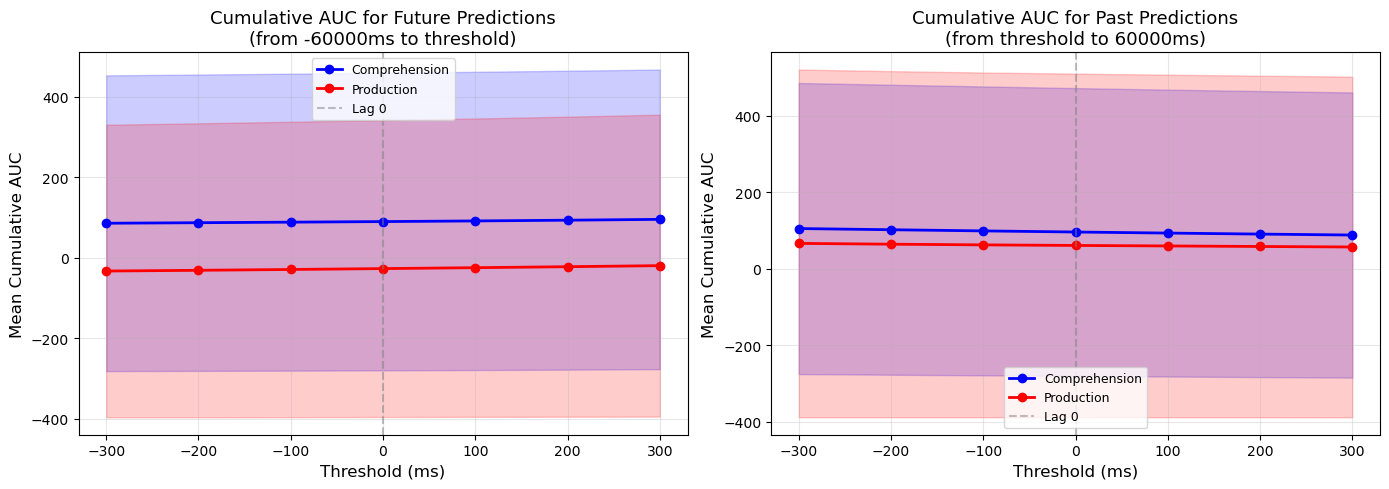

In [32]:
# Plot: AUC vs threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Future - cumulative AUC up to threshold
future_data = auc_results[auc_results['direction'] == 'future'].copy()
future_summary = future_data.groupby(['mode', 'threshold'])['auc'].agg(['mean', 'std', 'count']).reset_index()

for mode, color in [('comp', 'blue'), ('prod', 'red')]:
    mode_data = future_summary[future_summary['mode'] == mode]
    label = 'Comprehension' if mode == 'comp' else 'Production'
    axes[0].plot(mode_data['threshold'], mode_data['mean'], 
                marker='o', label=label,
                color=color, linewidth=2)
    axes[0].fill_between(mode_data['threshold'], 
                         mode_data['mean'] - mode_data['std'], 
                         mode_data['mean'] + mode_data['std'],
                         alpha=0.2, color=color)

axes[0].axvline(0, ls='--', color='gray', alpha=0.5, label='Lag 0')
axes[0].set_xlabel('Threshold (ms)', fontsize=12)
axes[0].set_ylabel('Mean Cumulative AUC', fontsize=12)
axes[0].set_title('Cumulative AUC for Future Predictions\n(from -60000ms to threshold)', fontsize=13)
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Past - cumulative AUC from threshold onward
past_data = auc_results[auc_results['direction'] == 'past'].copy()
past_summary = past_data.groupby(['mode', 'threshold'])['auc'].agg(['mean', 'std', 'count']).reset_index()

for mode, color in [('comp', 'blue'), ('prod', 'red')]:
    mode_data = past_summary[past_summary['mode'] == mode]
    label = 'Comprehension' if mode == 'comp' else 'Production'
    axes[1].plot(mode_data['threshold'], mode_data['mean'], 
                marker='o', label=label,
                color=color, linewidth=2)
    axes[1].fill_between(mode_data['threshold'], 
                         mode_data['mean'] - mode_data['std'], 
                         mode_data['mean'] + mode_data['std'],
                         alpha=0.2, color=color)

axes[1].axvline(0, ls='--', color='gray', alpha=0.5, label='Lag 0')
axes[1].set_xlabel('Threshold (ms)', fontsize=12)
axes[1].set_ylabel('Mean Cumulative AUC', fontsize=12)
axes[1].set_title('Cumulative AUC for Past Predictions\n(from threshold to 60000ms)', fontsize=13)
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

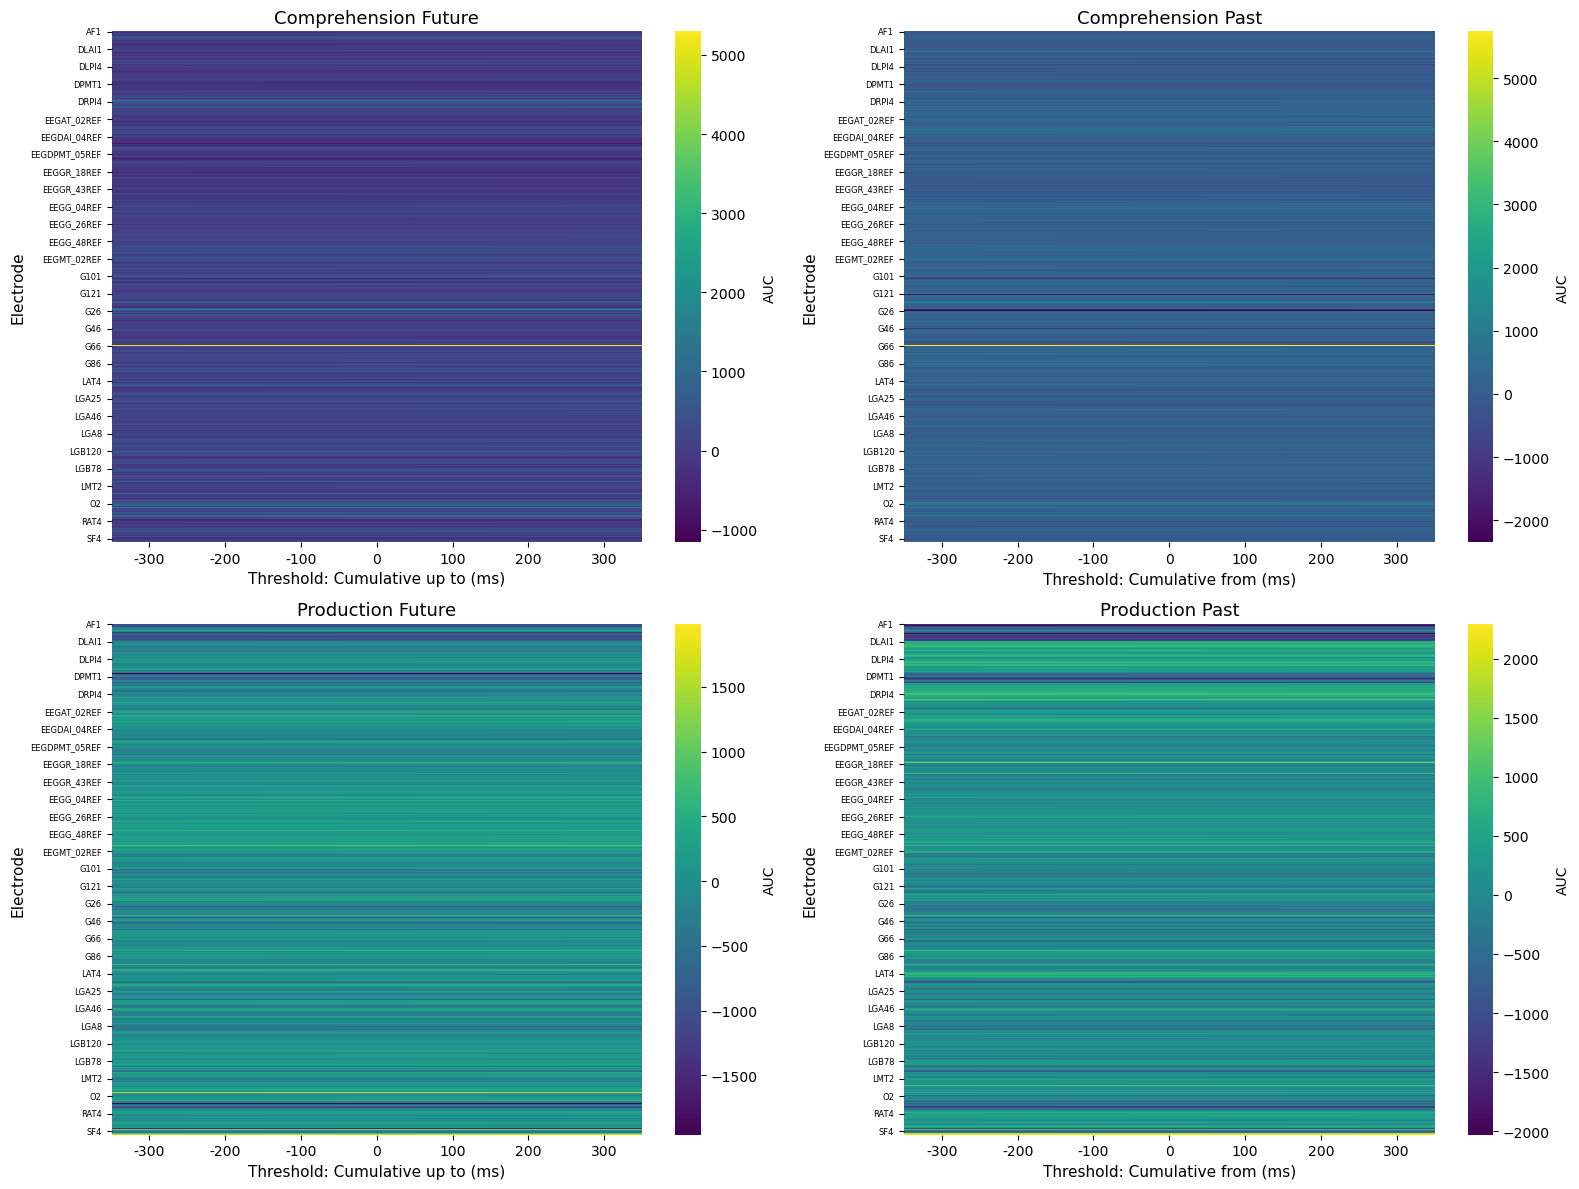

In [33]:
# Heatmap: AUC across conditions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

conditions = [
    ('comp', 'future', 'Comprehension Future', axes[0, 0]),
    ('comp', 'past', 'Comprehension Past', axes[0, 1]),
    ('prod', 'future', 'Production Future', axes[1, 0]),
    ('prod', 'past', 'Production Past', axes[1, 1])
]

for mode, direction, title, ax in conditions:
    data = auc_results[(auc_results['mode'] == mode) & (auc_results['direction'] == direction)].copy()
    
    # Create pivot table for heatmap using threshold
    pivot = data.groupby(['electrode', 'threshold'])['auc'].mean().reset_index()
    pivot_wide = pivot.pivot(index='electrode', columns='threshold', values='auc')
    
    if direction == 'future':
        xlabel = 'Threshold: Cumulative up to (ms)'
    else:
        xlabel = 'Threshold: Cumulative from (ms)'
    
    # Plot heatmap
    sns.heatmap(pivot_wide, ax=ax, cmap='viridis', cbar_kws={'label': 'AUC'})
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Electrode', fontsize=11)
    ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.show()

In [ ]:
# # Save results to CSV
# output_path = '/scratch/gpfs/HASSON/ij9216/projects/code/247/247-plotting/results/auc_results.csv'
# auc_results.to_csv(output_path, index=False)
# print(f"Results saved to: {output_path}")